/tmp/ipykernel_58/551145723.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean_Global_Payment_Share_Percentage', y='Currency', data=avg_payment_share.head(10), palette='plasma')


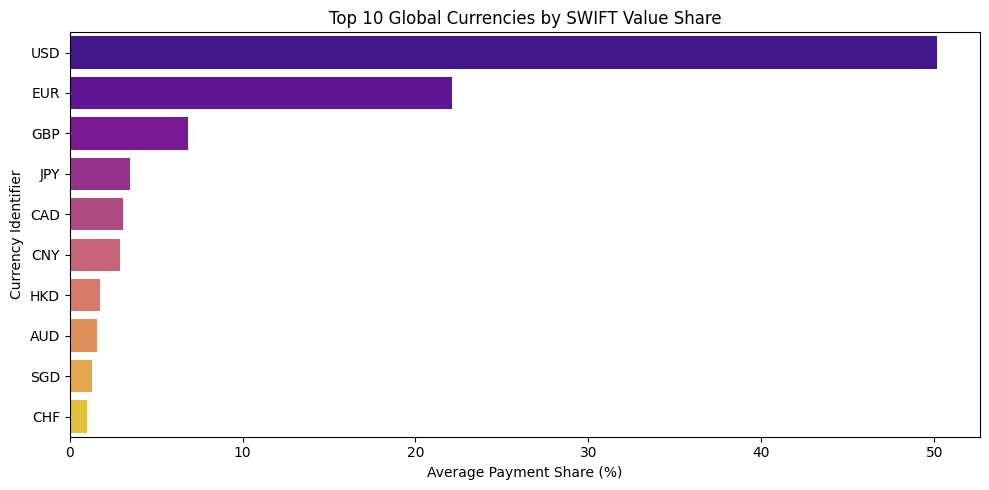

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

def find_kaggle_file(filename):
    input_dir = '/kaggle/input'
    for root, dirs, files in os.walk(input_dir):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename}")

swift_df = pd.read_csv(find_kaggle_file('swift_currency_tracker_all_reports.csv'))

swift_df.columns = swift_df.columns.str.strip()

payment_share_df = swift_df[swift_df['metric'] == 'Global Payment Share'].copy()
payment_share_df['value'] = pd.to_numeric(payment_share_df['value'], errors='coerce')

avg_payment_share = (payment_share_df.groupby('currency_or_economy')['value']
                     .mean()
                     .sort_values(ascending=False)
                     .reset_index())
avg_payment_share.columns = ['Currency', 'Mean_Global_Payment_Share_Percentage']


with PdfPages('task2_payment_shares.pdf') as pdf:
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Mean_Global_Payment_Share_Percentage', y='Currency', data=avg_payment_share.head(10), palette='plasma')
    plt.title('Top 10 Global Currencies by SWIFT Value Share')
    plt.xlabel('Average Payment Share (%)')
    plt.ylabel('Currency Identifier')
    plt.tight_layout()
    pdf.savefig()  # Saves your chart artifact cleanly
    plt.show()
    plt.close()